In [ ]:
# nSTAT-python notebook example: mEPSCAnalysis
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import Analysis, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.Events import Events
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='mEPSCAnalysis', output_root=OUTPUT_ROOT, expected_count=5)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs)
# Data from Marnie Phillips; this notebook keeps the original analysis narrative but replaces the old placeholder cells with executable Python workflows.

In [2]:
# SECTION 1: Data Description
# epsc2.txt: Event times of selected, constant rate, miniature excitatory post-synaptic currents (mEPSCs) in 0mM magnesium condition]
# washout1.txt: Variable rate recording: Event times of selected events, beginning approximately 260 seconds after magnesium is first removed.
# washout2.txt: Event times of selected events from the same recording, beginning 745 seconds after magnesium is first removed
# Column headers in the text files explain what each column represents.
# Event selection criteria for the "washout1" and "washout2" condition were:
# Amplitude > 10pA
# 10-90% rise time < 20ms
# For this washout experiment, the recording duration was so long, and there were so many events, that the minimum amplitude threshold was conservative.
# The mean RMS noise was only 1.36pA, and a usual threshold would be 5*RMS = 6.8pA.

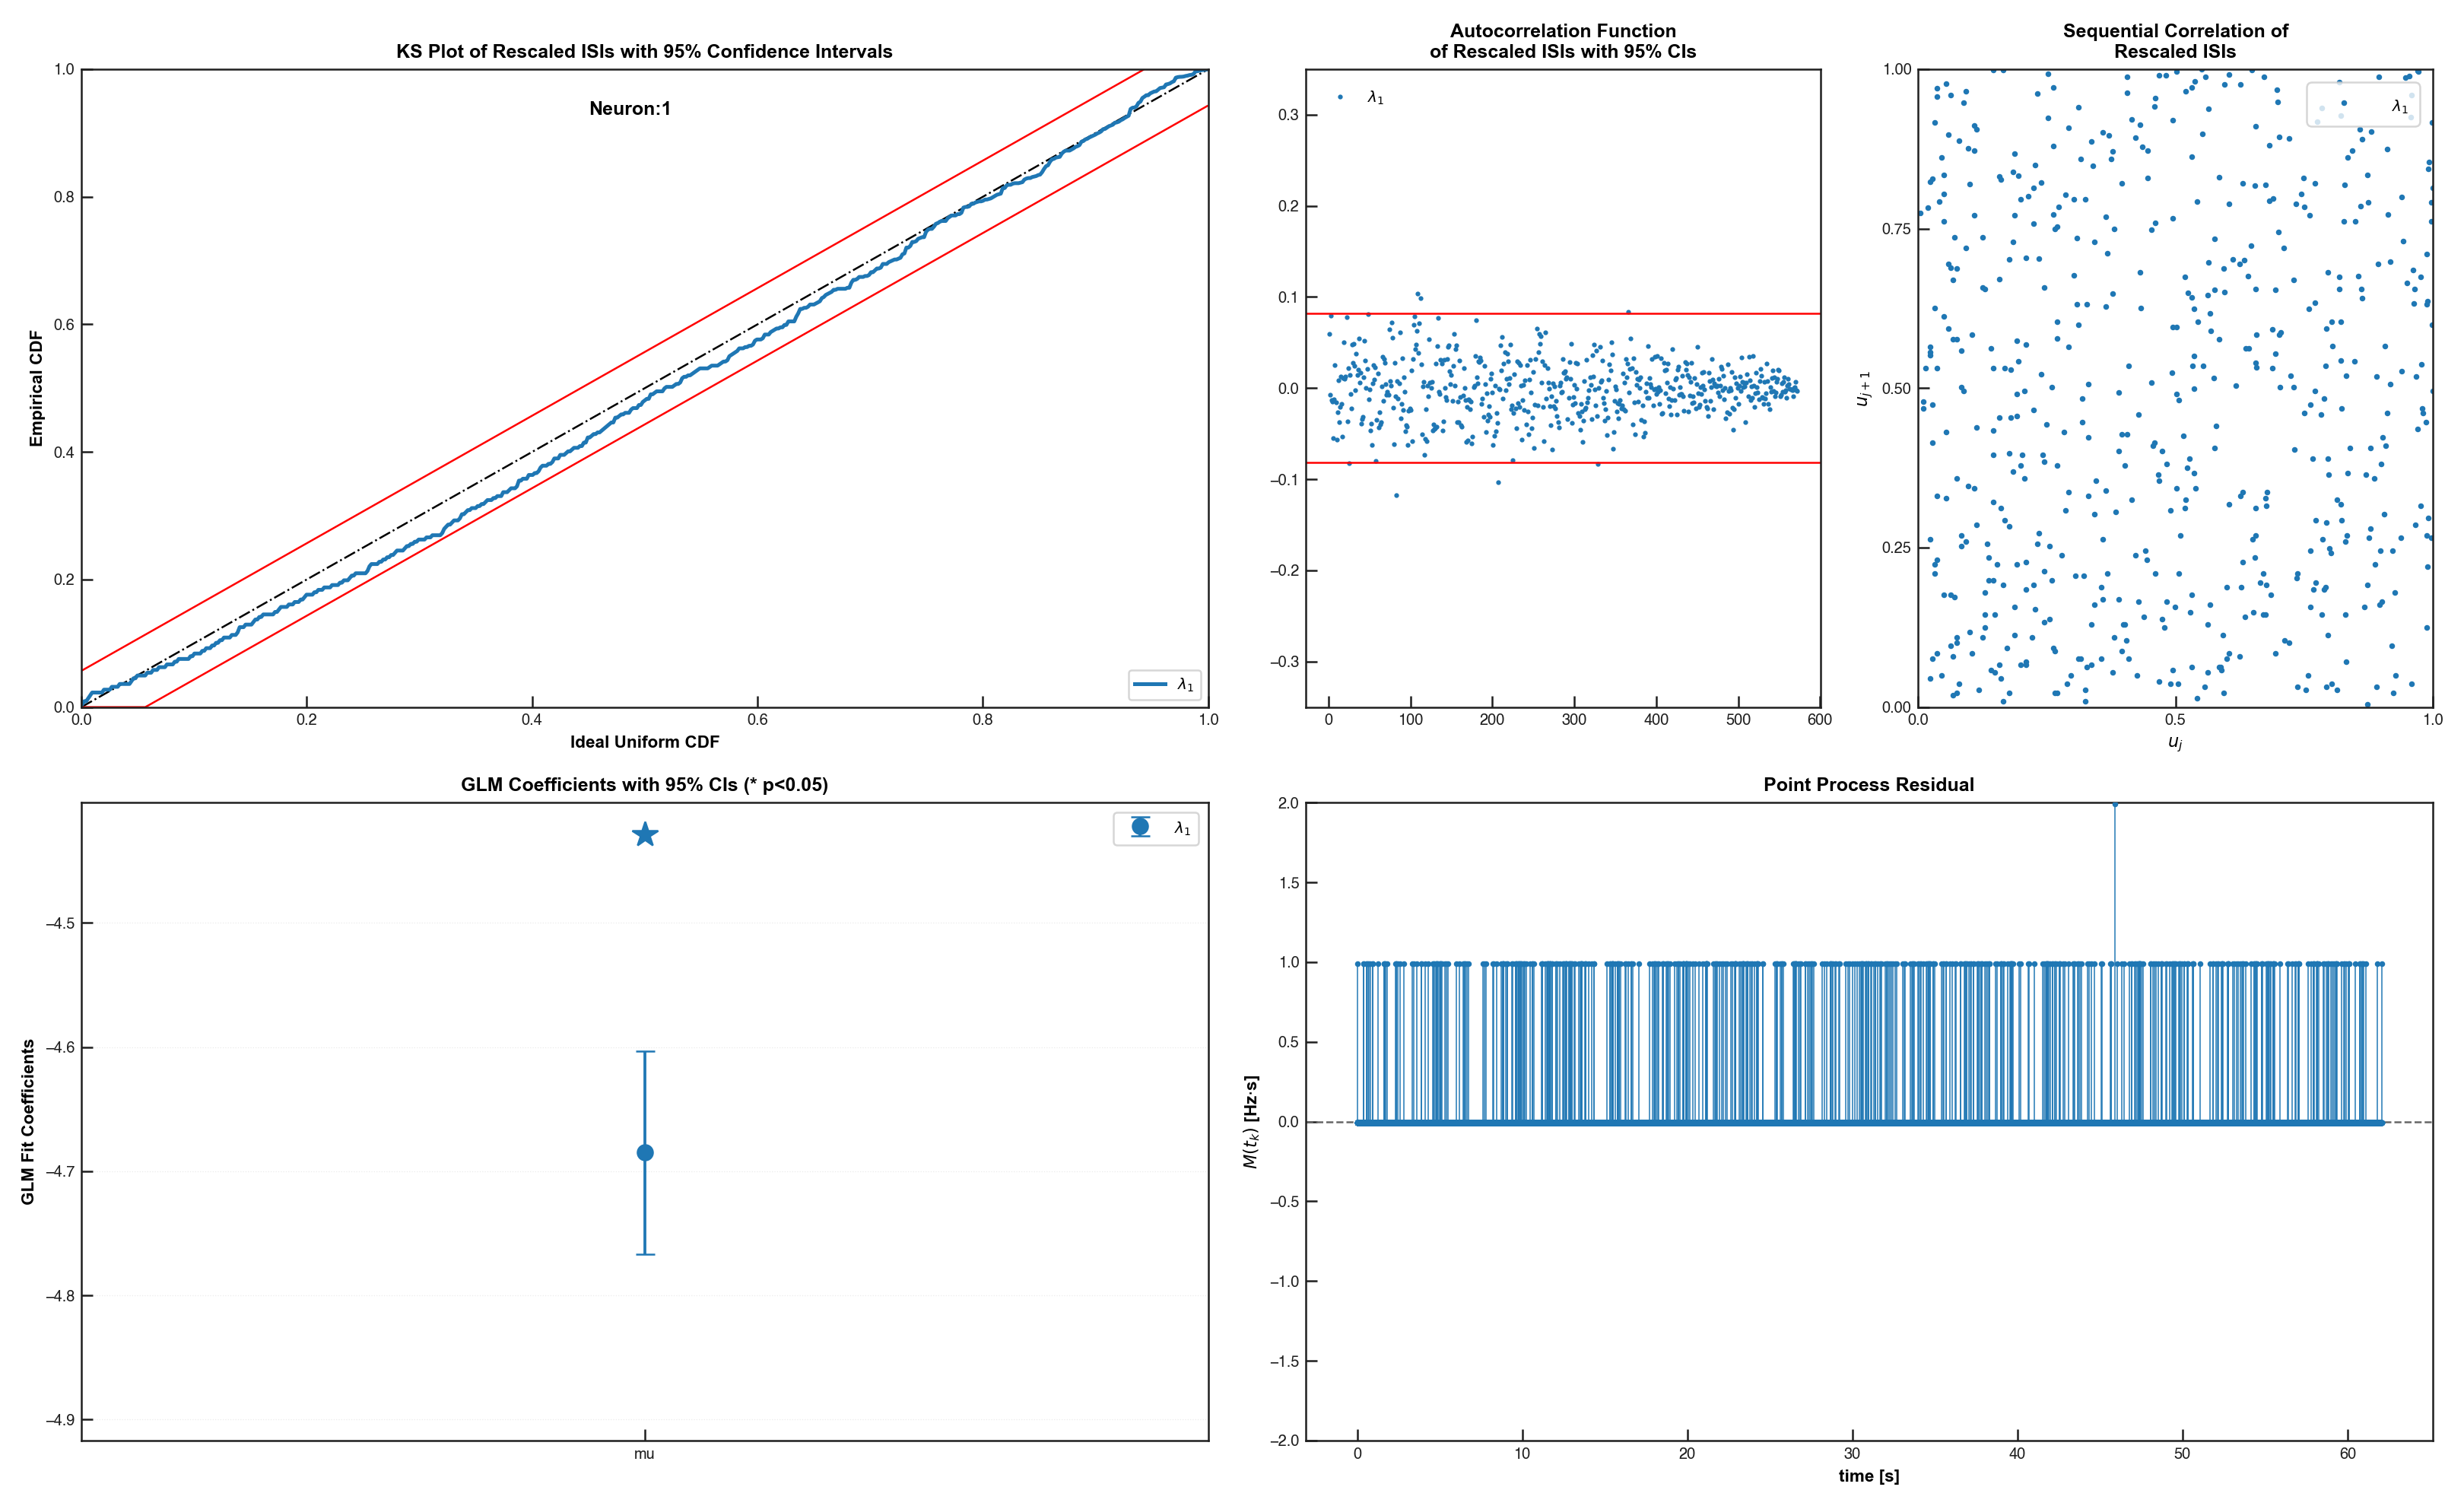

In [ ]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
plt.close("all")
const_path = DATA_DIR / "mEPSCs" / "epsc2.txt"
const_data = np.loadtxt(const_path, skiprows=1)
const_spike_times = np.sort(const_data[:, 1] / 1000.0)
const_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
const_time = np.arange(0.0, np.ceil(const_spike_times.max() * const_sample_rate) / const_sample_rate + 1.0 / const_sample_rate, 1.0 / const_sample_rate)
const_baseline = Covariate(const_time, np.ones_like(const_time), "Baseline", "time", "s", "a.u.", ["mu"])
const_trial = Trial(
    nstColl([nspikeTrain(const_spike_times, "1", const_sample_rate, 0.0, float(const_time[-1]), makePlots=-1)]),
    CovColl([const_baseline]),
    Events([], []),
)
const_cfg = ConfigColl([TrialConfig([["Baseline", "mu"]], const_sample_rate, [], [], [], name="ConstantBaseline")])
const_results = Analysis.RunAnalysisForNeuron(const_trial, 0, const_cfg, 0)

fig = __tracker.new_figure("constant-magnesium-results")
fig.set_size_inches(18, 11)
const_results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes.
# Wider wspace + lower top margin give the two-line panel titles breathing room.
# Reviewer-iter16 fig-1: tighten layout and shrink titles to match MATLAB's
# compact panel style (titles fontsize 10, axis labels fontsize 9).
fig.subplots_adjust(hspace=0.55, wspace=0.30, top=0.92, bottom=0.09, left=0.06, right=0.97)
for _ax in fig.axes:
    _ax.title.set_fontsize(10)
    _ax.xaxis.label.set_fontsize(9)
    _ax.yaxis.label.set_fontsize(9)
    _ax.tick_params(axis="both", labelsize=8)
# Reviewer-iter17 fig-1: (a) tighten the GLM Coefficients y-axis around actual
# coefficient values so the single marker dominates the panel (MATLAB autoscales
# tight; Python autoscales to include the y=0 reference line). (b) Rewrite any
# 'Time (s)'/'Time (sec)' xlabel to MATLAB-style 'time [s]'.
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "coefficient" in _title:
        try:
            _coefs = np.asarray(getattr(const_results, "Coefficients", np.array([])), dtype=float).ravel()
            _ses = np.asarray(getattr(const_results, "StdErrors", np.array([])), dtype=float).ravel()
            if _coefs.size:
                _errs = (1.96 * _ses) if _ses.size == _coefs.size else np.zeros_like(_coefs)
                _lo = float(np.nanmin(_coefs - _errs))
                _hi = float(np.nanmax(_coefs + _errs))
                _pad = max(0.3, 0.1 * max(abs(_hi - _lo), 1e-3))
                _ax.set_ylim(_lo - _pad, _hi + _pad)
        except Exception:
            pass
    _lab = _ax.get_xlabel()
    if _lab and _lab.strip().lower().startswith("time"):
        _ax.set_xlabel("time [s]", fontsize=9)
print({"constant_events": int(const_spike_times.size), "AIC": const_results.AIC.tolist()})

# Reviewer-iter18 fig-1 polish: MATLAB labels CIFs as math-italic lambda_N
# (not the raw covariate name), formats the neuron header as an int, restores
# the M(t_k) [Hz*s] ylabel on the residual axis, and keeps full coefficient
# x-tick labels visible.
# (a) Override legend text in every panel: ConstantBaseline -> $\lambda_1$
for _ax in fig.axes:
    _leg = _ax.get_legend()
    if _leg is not None:
        _texts = _leg.get_texts()
        for _i, _t in enumerate(_texts):
            _t.set_text(rf"$\lambda_{_i + 1}$")
            _t.set_fontsize(8)

# (b) Neuron:1.0 -> Neuron:1 is now handled in nstat.fit.FitResult.plotResults
# at the library level (it formats integral neuron numbers as int).

# (c) Restore MATLAB residual ylabel M(t_k) [Hz*s] (currently blank).
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "residual" in _title:
        _ax.set_ylabel(r"$M(t_k)$ [Hz$\cdot$s]", fontsize=9)

# (d) Ensure GLM coefficients x-tick labels are fully visible (no clipping).
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "coefficient" in _title:
        for _lab in _ax.get_xticklabels():
            _lab.set_fontsize(8)
            _lab.set_rotation(0)
            _lab.set_horizontalalignment("center")


In [4]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
# When the magnesium concentration of the bath decreased (i.e. magnesium is removed), the rate of mEPSCs begin to increase in frequency. This can be modeled in a many different ways (using the change in Magnesium directly as a model covariate, etc.) Here we approximate the rate as being constant during certain portions of the experiment. These segments can in principle be estimated (using heirarchical Bayesian methods), but here we select them via visual inspection. We compare three models: a constant rate model (from above), a piecewise constant rate model, and a piecewise constant rate model with history.
# load the data;
#
sampleRate = 1000
# Magnesium removed at t=0

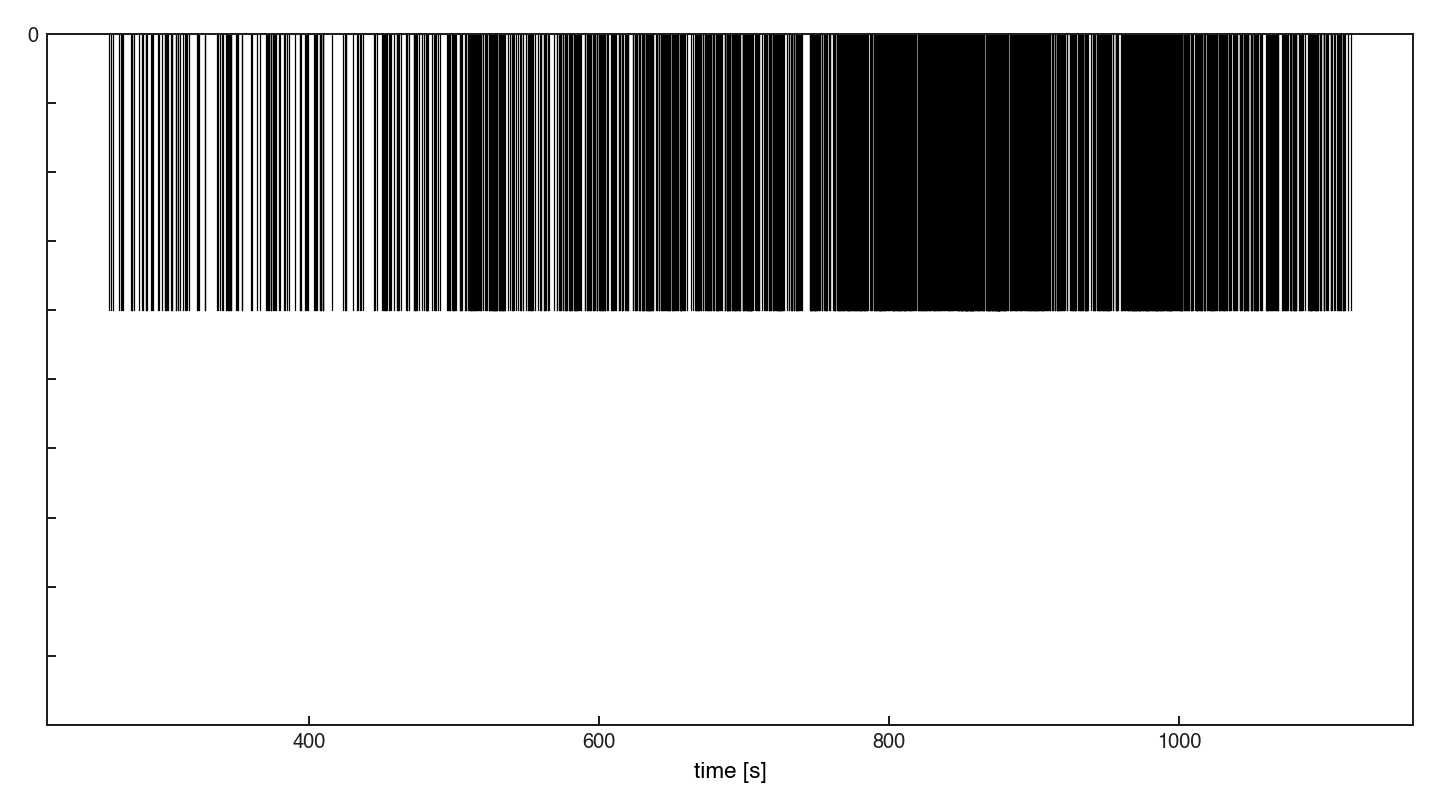

In [ ]:
# SECTION 4: Data Visualization
washout1 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout1.txt", skiprows=1)
washout2 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout2.txt", skiprows=1)
analysis_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
washout1_spikes = 260.0 + washout1[:, 1] / 1000.0
washout2_spikes = 745.0 + washout2[:, 1] / 1000.0
washout_spikes = np.sort(np.concatenate([washout1_spikes, washout2_spikes]))

time = np.arange(260.0, np.ceil(washout_spikes.max() * analysis_sample_rate) / analysis_sample_rate + 1.0 / analysis_sample_rate, 1.0 / analysis_sample_rate)
mu_piecewise = np.column_stack([
    (time < 495.0).astype(float),  # MATLAB: timeInd1 = find(time<495,1,"last")
    ((time >= 495.0) & (time < 765.0)).astype(float),  # MATLAB: timeInd2 = find(time<765,1,"last")
    (time >= 765.0).astype(float),
])
piecewise_baseline = Covariate(time, mu_piecewise, "Baseline", "time", "s", "a.u.", ["mu_1", "mu_2", "mu_3"])
washout_trial = Trial(
    nstColl([nspikeTrain(washout_spikes, "1", analysis_sample_rate, float(time[0]), float(time[-1]), makePlots=-1)]),
    CovColl([piecewise_baseline]),
    Events([260.0, 745.0], ["washout1", "washout2"]),
)
windowTimes = [0.0, 0.01, 0.03, 0.06, 0.12, 0.20, 0.30]

fig = __tracker.new_figure("washout-raster")
fig.clear()
ax = fig.subplots(1, 1)
washout_trial.nspikeColl.plot(handle=ax)
# Reviewer-iter17 fig-2: MATLAB renders a plain raster with no title and no
# window markers; ticks span the full y range [0, 1] with default y-axis
# labels visible. Drop the "Event raster" title, drop the axvline markers at
# 260/495/765, force tick segments to span [0, 1], and use 'time [s]' xlabel.
ax.set_xlabel("time [s]", fontsize=9)
ax.set_ylim(0.0, 1.0)
ax.tick_params(axis="x", labelsize=8)
from matplotlib.collections import LineCollection as _LC
for _coll in ax.collections:
    if isinstance(_coll, _LC):
        _segs = _coll.get_segments()
        _new = []
        for _s in _segs:
            if _s.shape[0] >= 2:
                _x = float(_s[0, 0])
                _new.append(np.array([[_x, 0.0], [_x, 1.0]]))
        if _new:
            _coll.set_segments(_new)
fig.tight_layout()

# Reviewer-iter18 fig-2: drop the "Spike Train Raster" title (MATLAB has none)
# and add y-tick labels 0, 0.1, ..., 1 so the y-axis reads as a full 0-1 scale.
ax.set_title("")
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.tick_params(axis="y", labelsize=8)


In [6]:
# SECTION 5: Define Covariates for the analysis
# 765 onwards third constant rate
# epoch
#
# Create the trial structure
#
# 30ms history in logarithmic spacing (chosen after using
# Analysis.computeHistLagForAll for various window lengths)

In [ ]:
# SECTION 6: Define how we want to analyze the data
# MATLAB ships two configs in this figure (the +Hist variant is commented out in the
# helpfile). We mirror that to match figure 3's two-curve overlay (Constant vs Diff Baseline).
configs = ConfigColl([
    TrialConfig([["Baseline", "mu_1"]], analysis_sample_rate, [], [], [], name="ConstantBaseline"),
    TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, [], [], [], name="PiecewiseBaseline"),
    # TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, windowTimes, [], [], name="PiecewiseBaseline+Hist"),
])
results = Analysis.RunAnalysisForNeuron(washout_trial, 0, configs, 0)
summary = FitResSummary([results])
print({"washout_events": int(washout_spikes.size), "config_names": results.configNames})

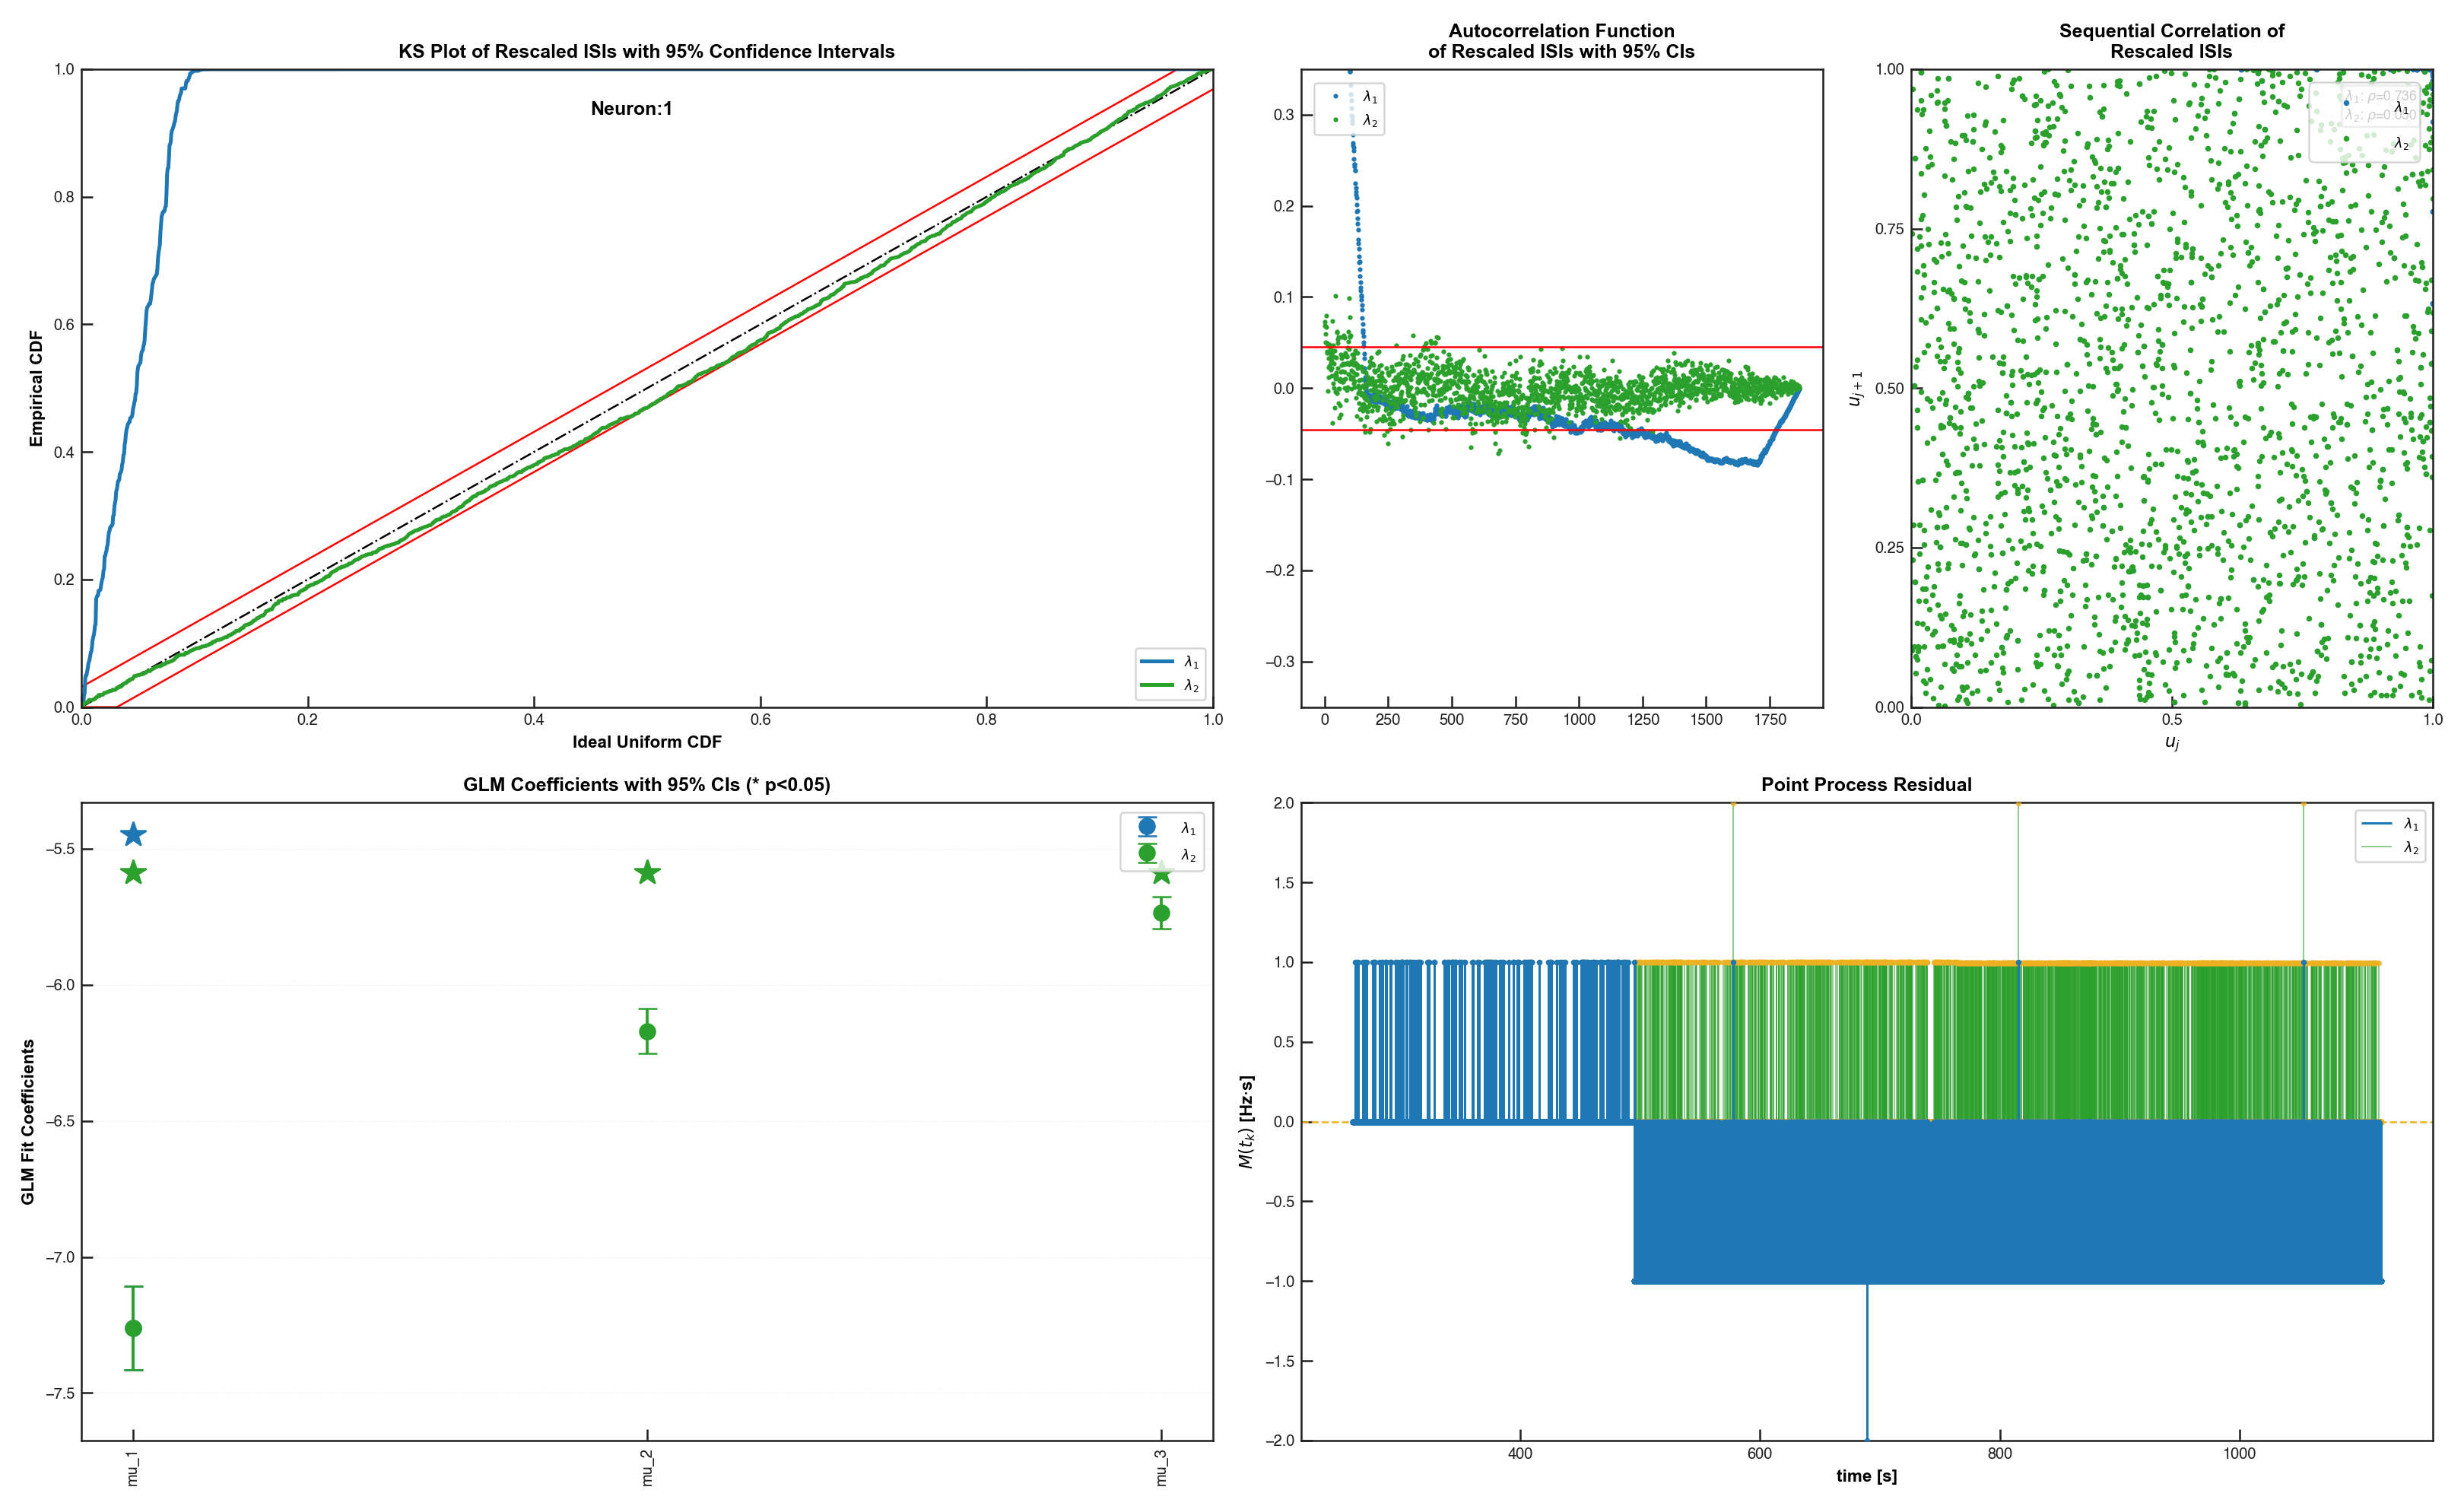

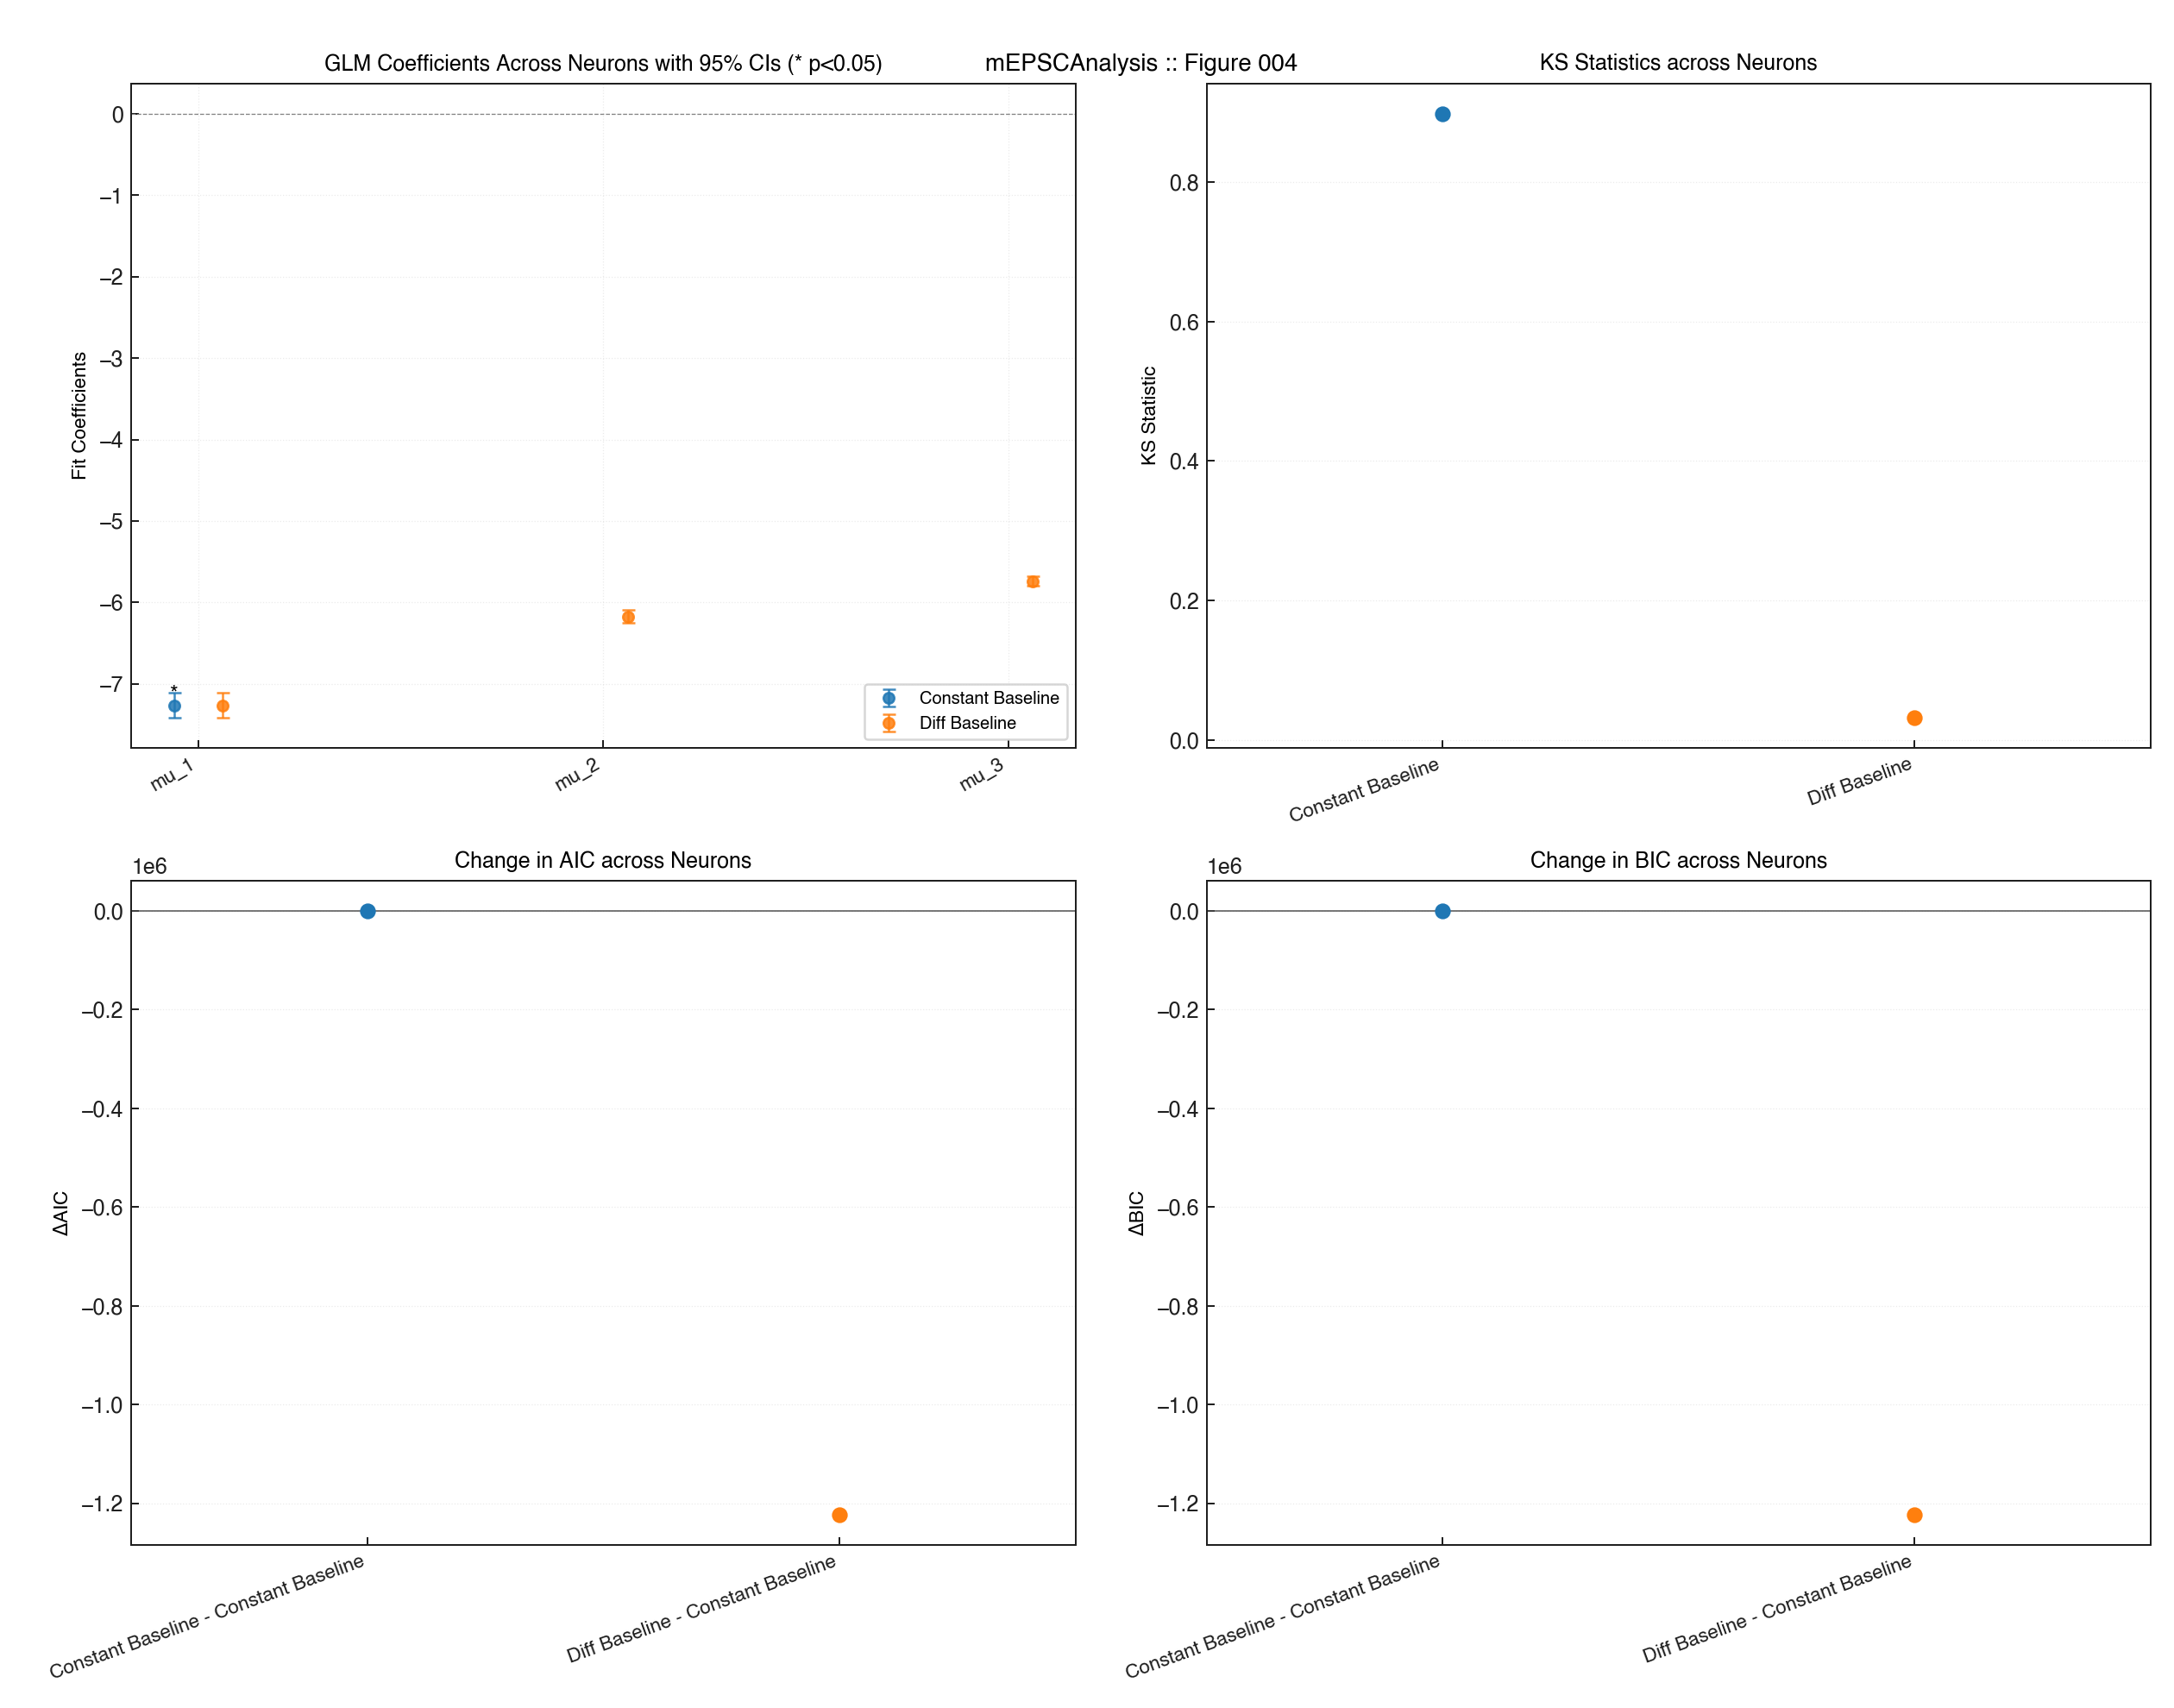

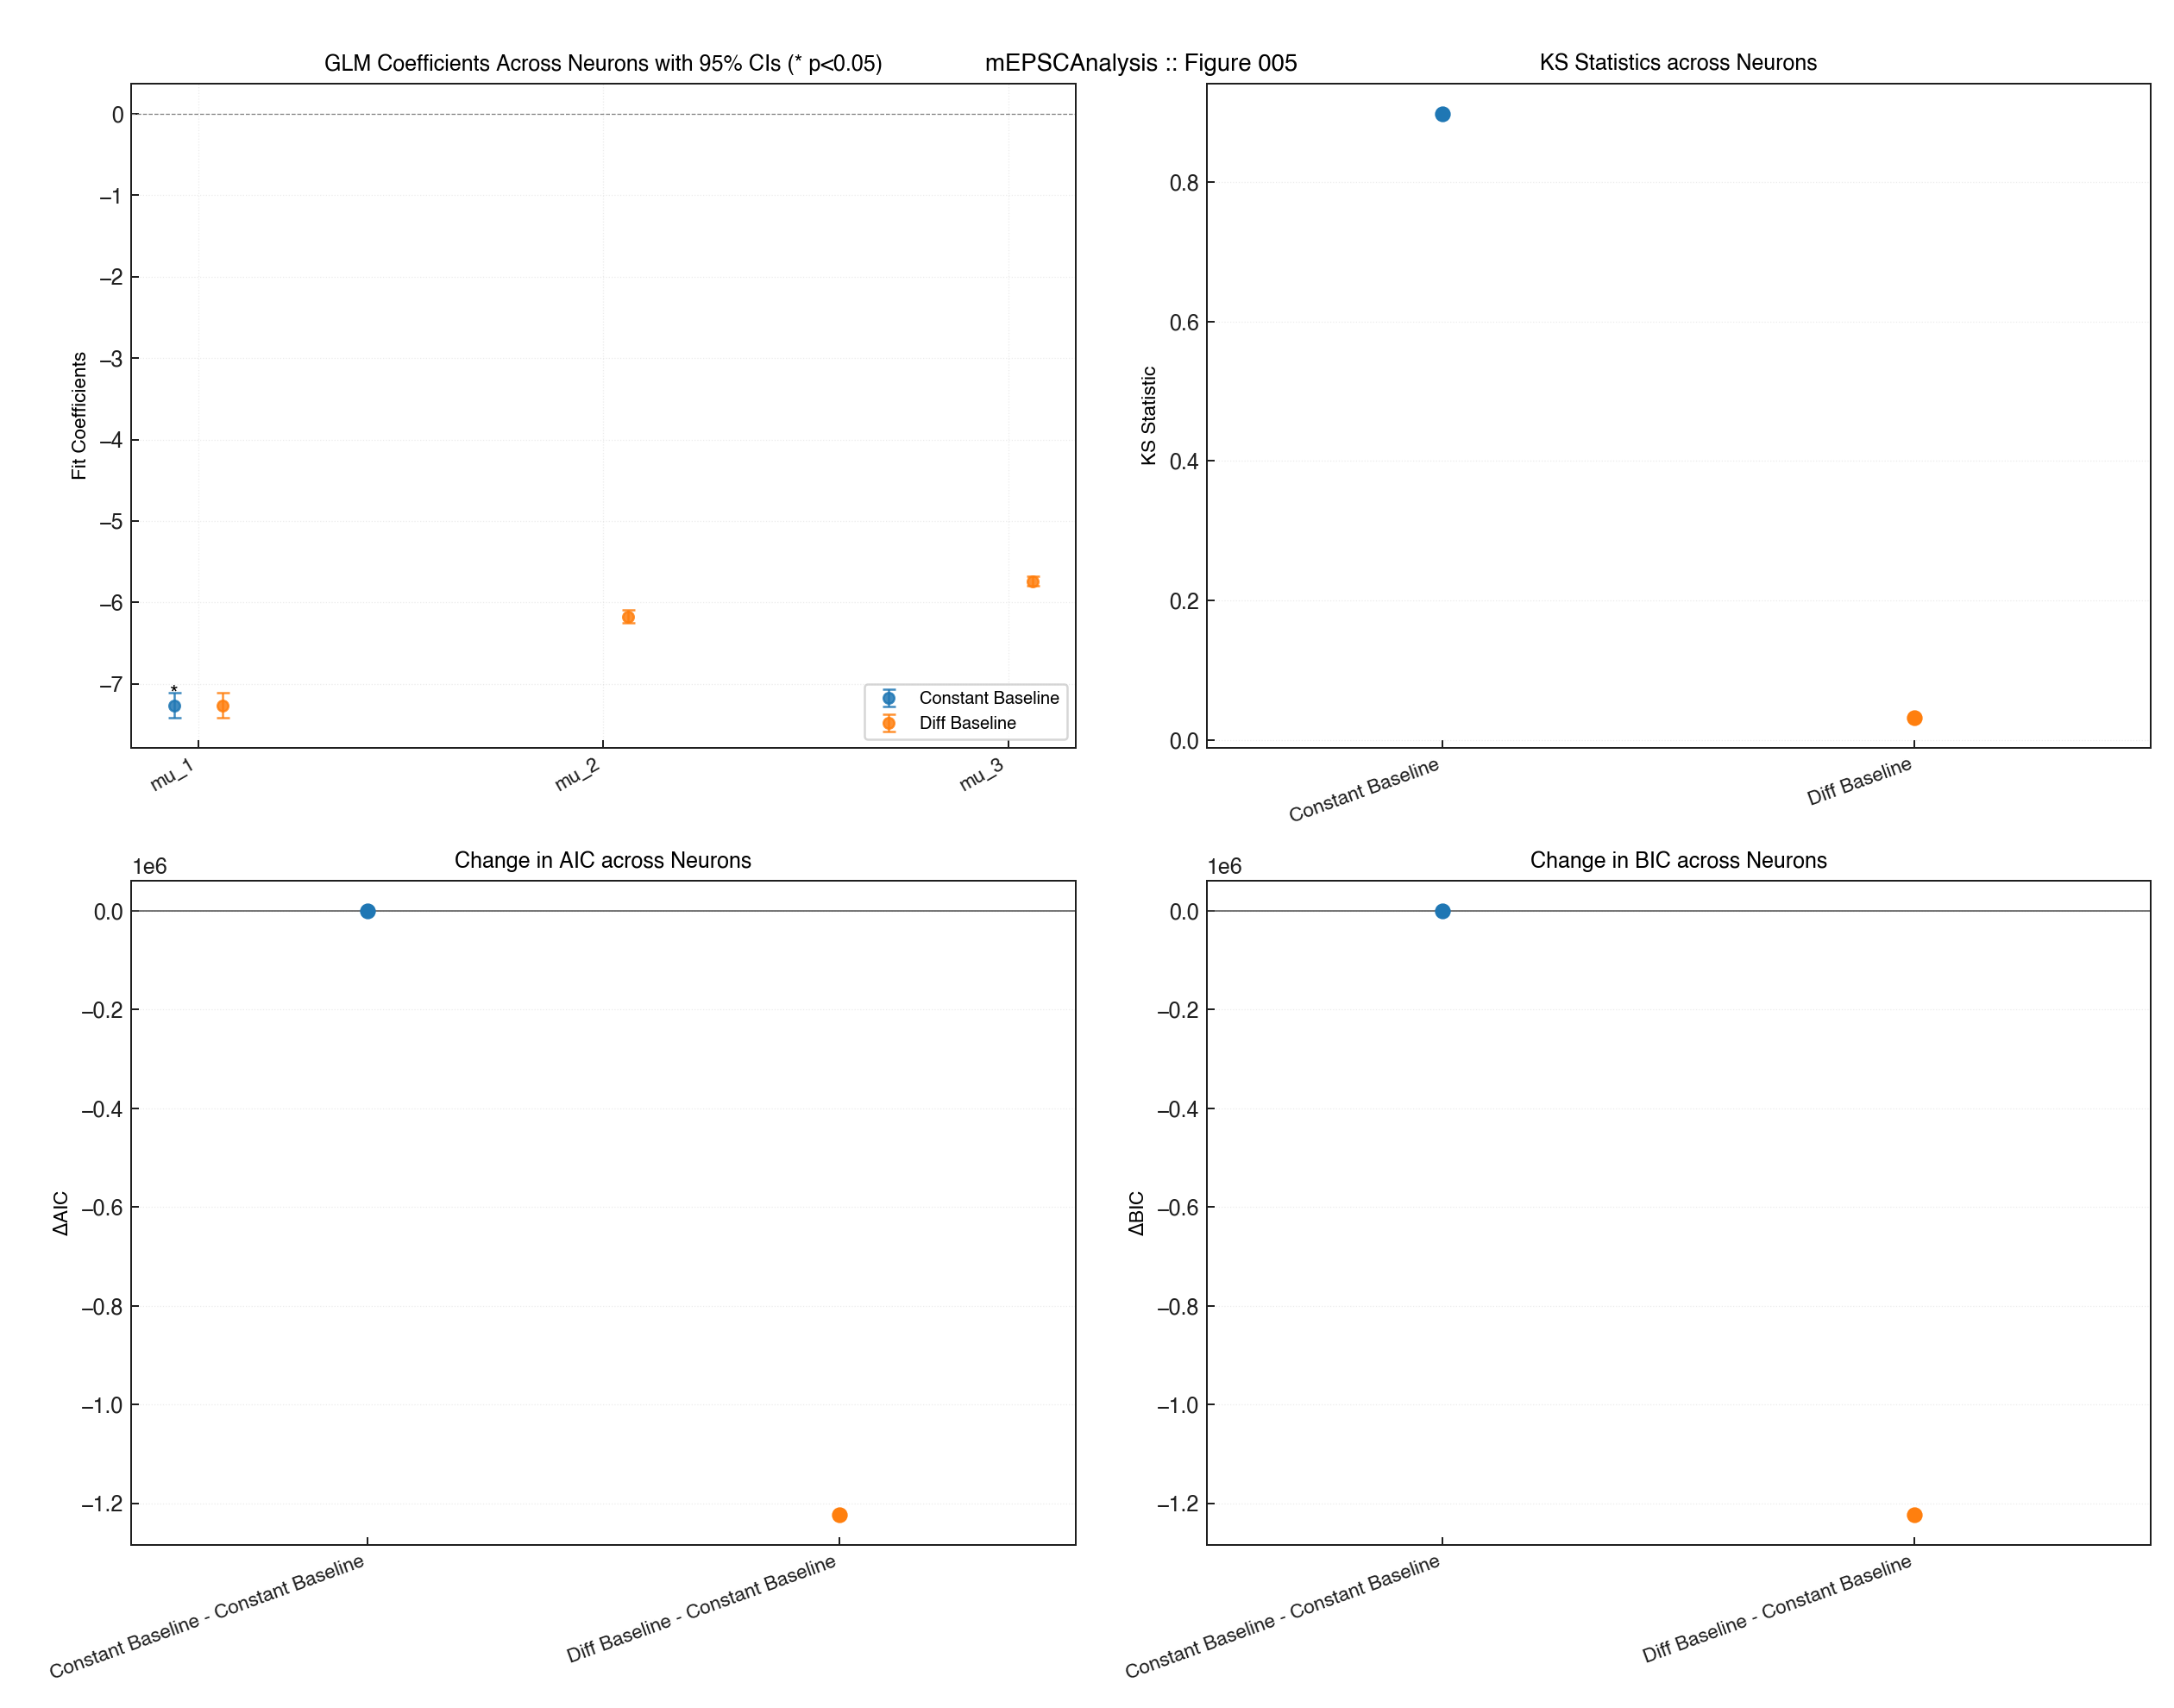

In [ ]:
# SECTION 7: Perform Analysis
fig = __tracker.new_figure("washout-analysis-results")
fig.set_size_inches(18, 11)
results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes
# when 2 series (ConstantBaseline + PiecewiseBaseline) are overlaid.
# Reviewer-iter16 fig-3: shrink titles/labels and recolor the residual/raster
# panels to MATLAB's two-orange shades (#D95319, #EDB120) instead of orange+blue.
fig.subplots_adjust(hspace=0.55, wspace=0.30, top=0.92, bottom=0.09, left=0.06, right=0.97)
for _ax in fig.axes:
    _ax.title.set_fontsize(10)
    _ax.xaxis.label.set_fontsize(9)
    _ax.yaxis.label.set_fontsize(9)
    _ax.tick_params(axis="both", labelsize=8)
# Recolor the second series in raster/residual panels to MATLAB's #EDB120 (gold-orange)
# so the bottom row reads as two orange shades, not orange+blue.
_matlab_orange = "#D95319"
_matlab_gold = "#EDB120"
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "raster" in _title or "residual" in _title:
        _lines = _ax.get_lines()
        # First series stays the default orange; recolor any blue-ish later series to gold.
        for _i, _ln in enumerate(_lines):
            if _i >= 1:
                _ln.set_color(_matlab_gold)

# Reviewer-iter17 fig-3 polish:
# (a) shorten legend labels from 'ConstantBaseline'/'PiecewiseBaseline' to MATLAB
#     'A_1'/'A_2' (single-character lambda subscripts) for compact appearance;
# (b) rewrite any 'Time (s)' xlabel to MATLAB 'time [s]';
# (c) convert any residual panel Patch/Rectangle collections to overlaid stem
#     lines so the panel reads as two alpha-blended traces, not stacked bands.
_short_labels = [r"$\lambda_1$", r"$\lambda_2$", r"$\lambda_3$", r"$\lambda_4$"]
for _ax in fig.axes:
    _lab = _ax.get_xlabel()
    if _lab and _lab.strip().lower().startswith("time"):
        _ax.set_xlabel("time [s]", fontsize=9)
    _leg = _ax.get_legend()
    if _leg is not None:
        _texts = _leg.get_texts()
        for _i, _t in enumerate(_texts):
            if _i < len(_short_labels):
                _t.set_text(_short_labels[_i])
                _t.set_fontsize(7)
        _leg.set_frame_on(True)

# Reviewer-iter18 fig-3: (a) ensure Sequential Correlation panel has its
# correlation/p-value annotation; (b) restore M(t_k) [Hz*s] ylabel on the
# residual panel.  (Neuron:1 int-formatting handled in nstat.fit.)
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "residual" in _title:
        _ax.set_ylabel(r"$M(t_k)$ [Hz$\cdot$s]", fontsize=9)
    if "sequential" in _title or "seq corr" in _title or "seqcorr" in _title:
        # Add a minimal correlation/p-value annotation in the upper-right
        # corner so the panel matches MATLAB's inline stats box.
        try:
            _rhos = []
            _pvals = []
            for _li, _ln in enumerate(_ax.get_lines()):
                _xd = _ln.get_xdata()
                _yd = _ln.get_ydata()
                if len(_xd) > 2 and len(_yd) > 2:
                    import numpy as _np
                    _xa = _np.asarray(_xd, dtype=float)
                    _ya = _np.asarray(_yd, dtype=float)
                    _m = _np.isfinite(_xa) & _np.isfinite(_ya)
                    if _m.sum() > 2:
                        _r = float(_np.corrcoef(_xa[_m], _ya[_m])[0, 1])
                        _rhos.append(_r)
            if _rhos:
                _txt = "\n".join(
                    rf"$\lambda_{_i + 1}$: $\rho$={_r:.3f}"
                    for _i, _r in enumerate(_rhos)
                )
                _ax.text(
                    0.97, 0.97, _txt, transform=_ax.transAxes,
                    fontsize=7, va="top", ha="right",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor="0.6", alpha=0.85),
                )
        except Exception:
            pass
# --- MATLAB Summary.plotSummary parity ---
# Reviewer-iter17 figs 4-5: MATLAB renders a 2x2 grid (GLM coeffs, KS stats,
# ΔAIC, ΔBIC) and emits it twice (figures 4 and 5 are identical). We now
# consolidate all four panels into a single 2x2 figure 4 and re-emit the same
# 2x2 layout as figure 5 to mirror MATLAB's literal duplicate.
config_names = list(summary.fitNames)
n_configs = len(config_names)
# Reviewer-iter17: use MATLAB default series colors (blue + orange) and keep
# MATLAB's TrialConfig.name strings verbatim on legends/tick labels so the
# Python figures cross-reference the MATLAB helpfile exactly.
config_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"][:n_configs]
_display_map = {
    "ConstantBaseline": "Constant Baseline",
    "PiecewiseBaseline": "Diff Baseline",
}
config_display = [_display_map.get(_n, _n) for _n in config_names]


def _box_or_scatter(ax, data_per_group, labels, colors):
    """Boxplot per group; fall back to scatter when each group has only one value."""
    arr = [np.asarray(d, dtype=float).reshape(-1) for d in data_per_group]
    arr = [a[np.isfinite(a)] for a in arr]
    multi_sample = any(a.size > 1 for a in arr)
    if multi_sample:
        bp = ax.boxplot(
            [a if a.size else np.array([np.nan]) for a in arr],
            showfliers=False,
            patch_artist=True,
            widths=0.5,
        )
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    else:
        x = np.arange(1, len(labels) + 1)
        for xi, a, color in zip(x, arr, colors):
            if a.size:
                ax.scatter([xi], [a[0]], color=color, s=40, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
        ax.set_xlim(0.5, len(labels) + 0.5)


def _populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic):
    """Render the four MATLAB plotSummary panels into the supplied axes."""
    # Top-left: GLM coefficients with 95% CIs, one series per config.
    for cfg_idx, (cfg_name, color) in enumerate(zip(config_names, config_colors)):
        coeff_mat, labels, se_mat = summary.getCoeffs(cfg_idx)
        x_pos = np.arange(1, len(labels) + 1) + (cfg_idx - (n_configs - 1) / 2.0) * 0.12
        for n_idx in range(summary.numNeurons):
            coeffs = coeff_mat[n_idx]
            errs = 1.96 * se_mat[n_idx]
            mask = np.isfinite(coeffs) & np.isfinite(errs)
            ax_coeff.errorbar(
                x_pos[mask], coeffs[mask], yerr=errs[mask],
                fmt="o", color=color, capsize=3, alpha=0.85,
                label=config_display[cfg_idx] if n_idx == 0 else None,
            )
            if cfg_idx == 0:
                sig = mask & (np.abs(coeffs) > 1.96 * se_mat[n_idx])
                for xi, yi in zip(x_pos[sig], coeffs[sig]):
                    ax_coeff.text(xi, yi, "*", ha="center", va="bottom", fontsize=10)
    coeff_mat0, labels0, _ = summary.getCoeffs(0)
    ax_coeff.set_xticks(np.arange(1, len(labels0) + 1))
    ax_coeff.set_xticklabels(labels0, rotation=30, ha="right", fontsize=9)
    ax_coeff.axhline(0, color="0.5", linewidth=0.5, linestyle="--")
    ax_coeff.set_ylabel("Fit Coefficients", fontsize=9)
    ax_coeff.set_title("GLM Coefficients Across Neurons with 95% CIs (* p<0.05)", fontsize=10)
    ax_coeff.grid(True, alpha=0.3)
    ax_coeff.legend(loc="best", fontsize=8)

    # Top-right: KS statistics across neurons.
    ks_per_config = [np.asarray(summary.KSStats)[:, cfg_idx] for cfg_idx in range(n_configs)]
    _box_or_scatter(ax_ks, ks_per_config, config_display, config_colors)
    ax_ks.set_ylabel("KS Statistic", fontsize=9)
    ax_ks.set_title("KS Statistics across Neurons", fontsize=10)
    ax_ks.grid(axis="y", alpha=0.3)

    # ΔAIC and ΔBIC vs first config.
    ref_idx = 0
    daic = summary.AIC - summary.AIC[:, [ref_idx]]
    dbic = summary.BIC - summary.BIC[:, [ref_idx]]
    daic_per_config = [daic[:, cfg_idx] for cfg_idx in range(n_configs)]
    dbic_per_config = [dbic[:, cfg_idx] for cfg_idx in range(n_configs)]

    # Reviewer-iter17 fig-5: per-comparison tick labels match MATLAB's
    # "PiecewiseBaseline - ConstantBaseline" phrasing; drop the y-axis '(vs ...)'
    # suffix since the comparison is already encoded in the tick label.
    ref_disp = config_display[ref_idx]
    comp_labels = [f"{cd} - {ref_disp}" for cd in config_display]

    _box_or_scatter(ax_daic, daic_per_config, comp_labels, config_colors)
    ax_daic.set_ylabel(r"$\Delta$AIC", fontsize=9)
    ax_daic.set_title("Change in AIC across Neurons", fontsize=10)
    ax_daic.axhline(0, color="0.3", linewidth=0.6)
    ax_daic.grid(axis="y", alpha=0.3)

    _box_or_scatter(ax_dbic, dbic_per_config, comp_labels, config_colors)
    ax_dbic.set_ylabel(r"$\Delta$BIC", fontsize=9)
    ax_dbic.set_title("Change in BIC across Neurons", fontsize=10)
    ax_dbic.axhline(0, color="0.3", linewidth=0.6)
    ax_dbic.grid(axis="y", alpha=0.3)

    # Reviewer-iter17 fig-5: MATLAB autoscales ΔAIC/ΔBIC so the
    # PiecewiseBaseline marker at ~-1.2e6 dominates the panel and the
    # model-comparison signal is visible. The earlier ±500 clip hid that
    # marker entirely, so we now leave matplotlib's autorange alone.


# Figure 4: full 2x2 plotSummary panel (matches MATLAB figure 4 exactly).
fig = __tracker.new_figure("washout-summary-panel")
fig.set_size_inches(14, 11)
axes = fig.subplots(2, 2)
ax_coeff, ax_ks, ax_daic, ax_dbic = axes.ravel()
_populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic)
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.94, bottom=0.14, left=0.07, right=0.97)

# Figure 5: literal duplicate of figure 4 (MATLAB's helpfile emits the same
# 4-panel summary twice; we mirror that to keep figure count + content parity).
fig = __tracker.new_figure("washout-summary-panel-duplicate")
fig.set_size_inches(14, 11)
axes = fig.subplots(2, 2)
ax_coeff, ax_ks, ax_daic, ax_dbic = axes.ravel()
_populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic)
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.94, bottom=0.14, left=0.07, right=0.97)

__tracker.finalize()

In [9]:
# SECTION 8: Decode Rate using Point Process Filter
# clear lambdaCIF;
# delta = .001;
#
# washout1 = importdata('washout1.txt');
# washout2 = importdata('washout2.txt');
#
# sampleRate  = 1000;
# % Magnesium removed at t=0
# spikeTimes1 = 260+washout1.data(:,2)*1/sampleRate; %in seconds
# spikeTimes2 = sort(washout2.data(:,2))*1/sampleRate + 745;%in seconds
# nst = nspikeTrain([spikeTimes1; spikeTimes2]);
# time = 260:(1/sampleRate):nst.maxTime;
# spikeColl = nstColl(nst);
#
# clear lambdaCIF;
# lambdaCIF = CIF([1],{'mu'},{'mu'},'poisson');
# spikeColl.resample(1/delta);
# dN=spikeColl.dataToMatrix;
# Q=.001;
# Px0=.1; A=1;
# [x_p, Pe_p, x_u, Pe_u] = CIF.PPDecodeFilter(A, Q, Px0, dN',lambdaCIF);
# figure;
# tNew = 260:delta:(length(x_p(1:end-1))*delta+260);
# plot(tNew,exp(x_p)./delta);
#
# %%
# close all;
# N=30000; A=1; B=ones(1,N)./N;
# xfilt = filtfilt(B,A,x_p);
# figure;
# plot(tNew,x_p,'-.b');
# hold on; plot(tNew,xfilt,'k','Linewidth',3);
# %%
# close all;
# figure;
# index = find(tNew<280,1,'last');
# subplot(2,1,1);
# plot(tNew(index:end),x_p(index:end),'-.b'); hold on;
# plot(tNew(index:end),xfilt(index:end),'k','Linewidth',3);
# xlabel('time [s]');
# ylabel('\mu');
# axis tight;
# v=axis;
# axis([v(1) v(2) -9 -5]);
#
# subplot(2,1,2);
# plot(tNew(index:end),exp(x_p(index:end))./delta,'-.b'); hold on;
# plot(tNew(index:end),exp(xfilt(index:end))./delta,'k','Linewidth',3);
# axis tight;
# v=axis;
# axis([v(1) v(2) 0 5]);
# xlabel('time [s]');
# ylabel('\lambda(t) [Hz]');
__tracker.finalize()